In [ ]:
import MOBSTERm.model_mobster_parallel as model_mobster_mv
import numpy as np
import pandas as pd
import pyro.distributions as dist
from scipy import stats

import torch
import seaborn as sns

import matplotlib.pyplot as plt

from MOBSTERm.plot_functions import *
from MOBSTERm.BoundedPareto import BoundedPareto
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
data = pd.read_csv("data/test_data.csv")
data

,mutation_id,chr,from,ref,alt,causes,classes,to,Sample.A.NV,Sample.B.NV,Sample.A.DP,Sample.B.DP,Sample.A.VAF,Sample.B.VAF,chr_pos
0,14_16008308_16008308_T_G,14,16008308,T,G,SBS5,passenger,16008308,5,0,77,87,0.064935,0.000000,16008308
1,14_16021016_16021016_C_A,14,16021016,C,A,SBS5,passenger,16021016,23,0,83,79,0.277108,0.000000,16021016
2,14_16038028_16038028_C_G,14,16038028,C,G,SBS5,passenger,16038028,0,33,79,75,0.000000,0.440000,16038028
3,14_16053575_16053575_G_A,14,16053575,G,A,SBS5,passenger,16053575,0,34,87,75,0.000000,0.453333,16053575
4,14_16072811_16072811_G_A,14,16072811,G,A,SBS1,passenger,16072811,12,0,95,63,0.126316,0.000000,16072811
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16587,19_58551962_58551962_G_A,19,58551962,G,A,SBS1,pre-neoplastic,58551962,27,49,62,81,0.435484,0.604938,58551962
16588,19_58557357_58557357_C_T,19,58557357,C,T,SBS5,passenger,58557357,6,0,80,77,0.075000,0.000000,58557357
16589,19_58559817_58559817_A_G,19,58559817,A,G,SBS5,passenger,58559817,0,14,83,69,0.000000,0.202899,58559817
16590,19_58581905_58581905_C_T,19,58581905,C,T,SBS1,passenger,58581905,0,50,74,91,0.000000,0.549451,58581905


In [3]:
sets = ['Sample.A', 'Sample.B']

NV_list = []
DP_list = []

for s in sets:
    print(s)
    NV = torch.tensor(data[f'{s}.NV'].to_numpy())
    DP = torch.tensor(data[f'{s}.DP'].to_numpy())
    
    NV_list.append(NV.view(-1, 1))
    DP_list.append(DP.view(-1, 1))

NV = torch.cat(NV_list, dim=1)
DP = torch.cat(DP_list, dim=1)
purity = [1,1]
print(NV.shape, DP.shape)
K_list = [5,6,7,8,9]
seed_list = [40,41]

Sample.A
Sample.B
torch.Size([16592, 2]) torch.Size([16592, 2])


In [4]:
mut_id = data['mutation_id'].tolist()

In [5]:
import os
n_jobs = min(len(K_list) * len(seed_list), os.cpu_count())
n_jobs

8

In [6]:
# pip install joblib # install if needed 

In [7]:
# n_jobs=1 runs sequentially, one (K, seed) combination at a time
# n_jobs=-1 to use all available CPU
# n_jobs=x  to use x CPUs
mb = model_mobster_mv.fit(
    NV=NV, DP=DP, mut_id=mut_id,
    num_iter=1500, K=K_list,
    seed_list=seed_list, lr=0.01,
    purity=purity,
    n_jobs=-1  # to use all available CPU
)

RUN WITH K = 5 AND SEED = 40
RUN WITH K = 6 AND SEED = 40
RUN WITH K = 6 AND SEED = 41
RUN WITH K = 7 AND SEED = 41
RUN WITH K = 7 AND SEED = 40
RUN WITH K = 5 AND SEED = 41
RUN WITH K = 8 AND SEED = 40
RUN WITH K = 8 AND SEED = 41
Iteration 0: Loss = 1666433164.720292
Iteration 0: Loss = 1655982575.6867716
Iteration 0: Loss = 1472297579.9775593
Iteration 0: Loss = 1466827469.9259393
Iteration 0: Loss = 1448811393.8156493
Iteration 0: Loss = 1444142423.4316814
Iteration 0: Loss = 1425545963.4647233
Iteration 0: Loss = 1425892085.2903037
Iteration 50: Loss = 1367317854.9876962
Iteration 50: Loss = 1365879899.8411965
Iteration 50: Loss = 1351877964.4061627
Iteration 50: Loss = 1355904137.778164
Iteration 50: Loss = 1335285171.9183164
Iteration 50: Loss = 1339828549.364459
Iteration 100: Loss = 1326407098.6002438
Iteration 100: Loss = 1324788062.75015
Iteration 50: Loss = 1327655296.9681678
Iteration 50: Loss = 1327810195.2807014
Iteration 100: Loss = 1327197857.0935256
Iteration 100: Los

In [9]:
for run in mb['runs']:
    print(f"K={run['n_components']}, ICL={run['icl']}, seed={run['seed']}")

K=7, ICL=162846.40625, seed=40
K=8, ICL=163310.03125, seed=41
K=6, ICL=163888.46875, seed=41
K=9, ICL=167048.640625, seed=40
K=5, ICL=818441.8125, seed=40


In [18]:
save_results(mb, save_folder= 'test_data')

/Users/elenarivaroli/Documents/GitHub/MOBSTERm/MOBSTERm/plot_functions.py:577: UserWarning: The palette list has more values (27) than needed (7), which may not be intended.
  ax.set_ylabel(y_col)


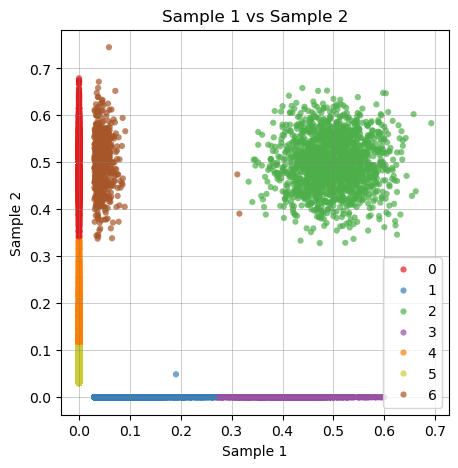

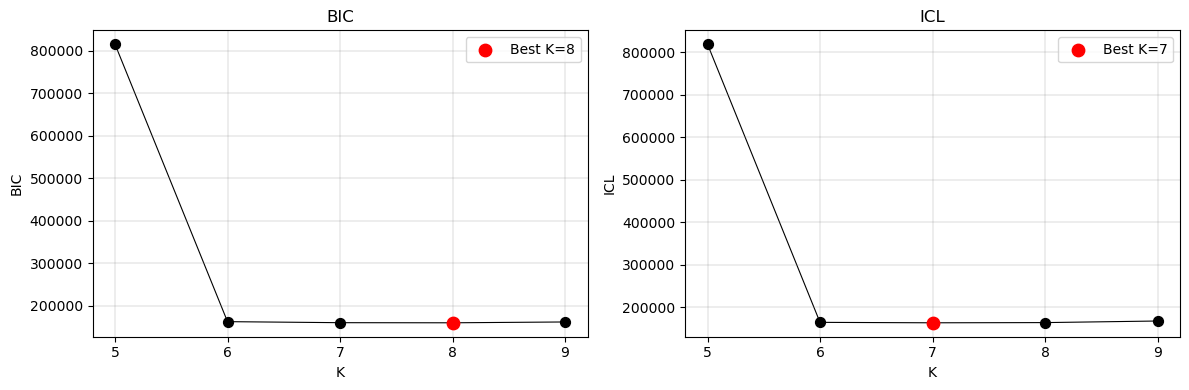

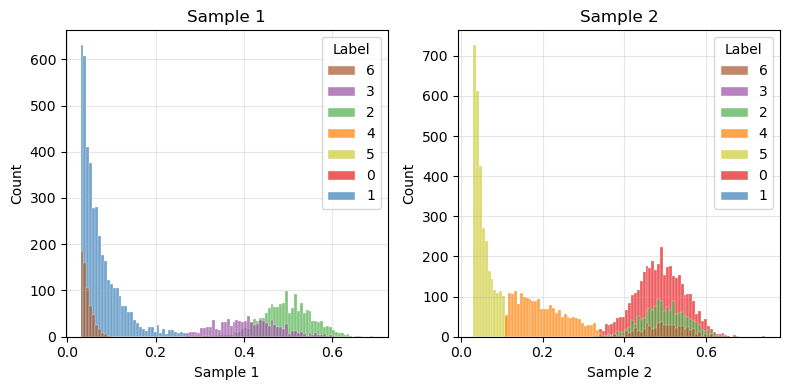

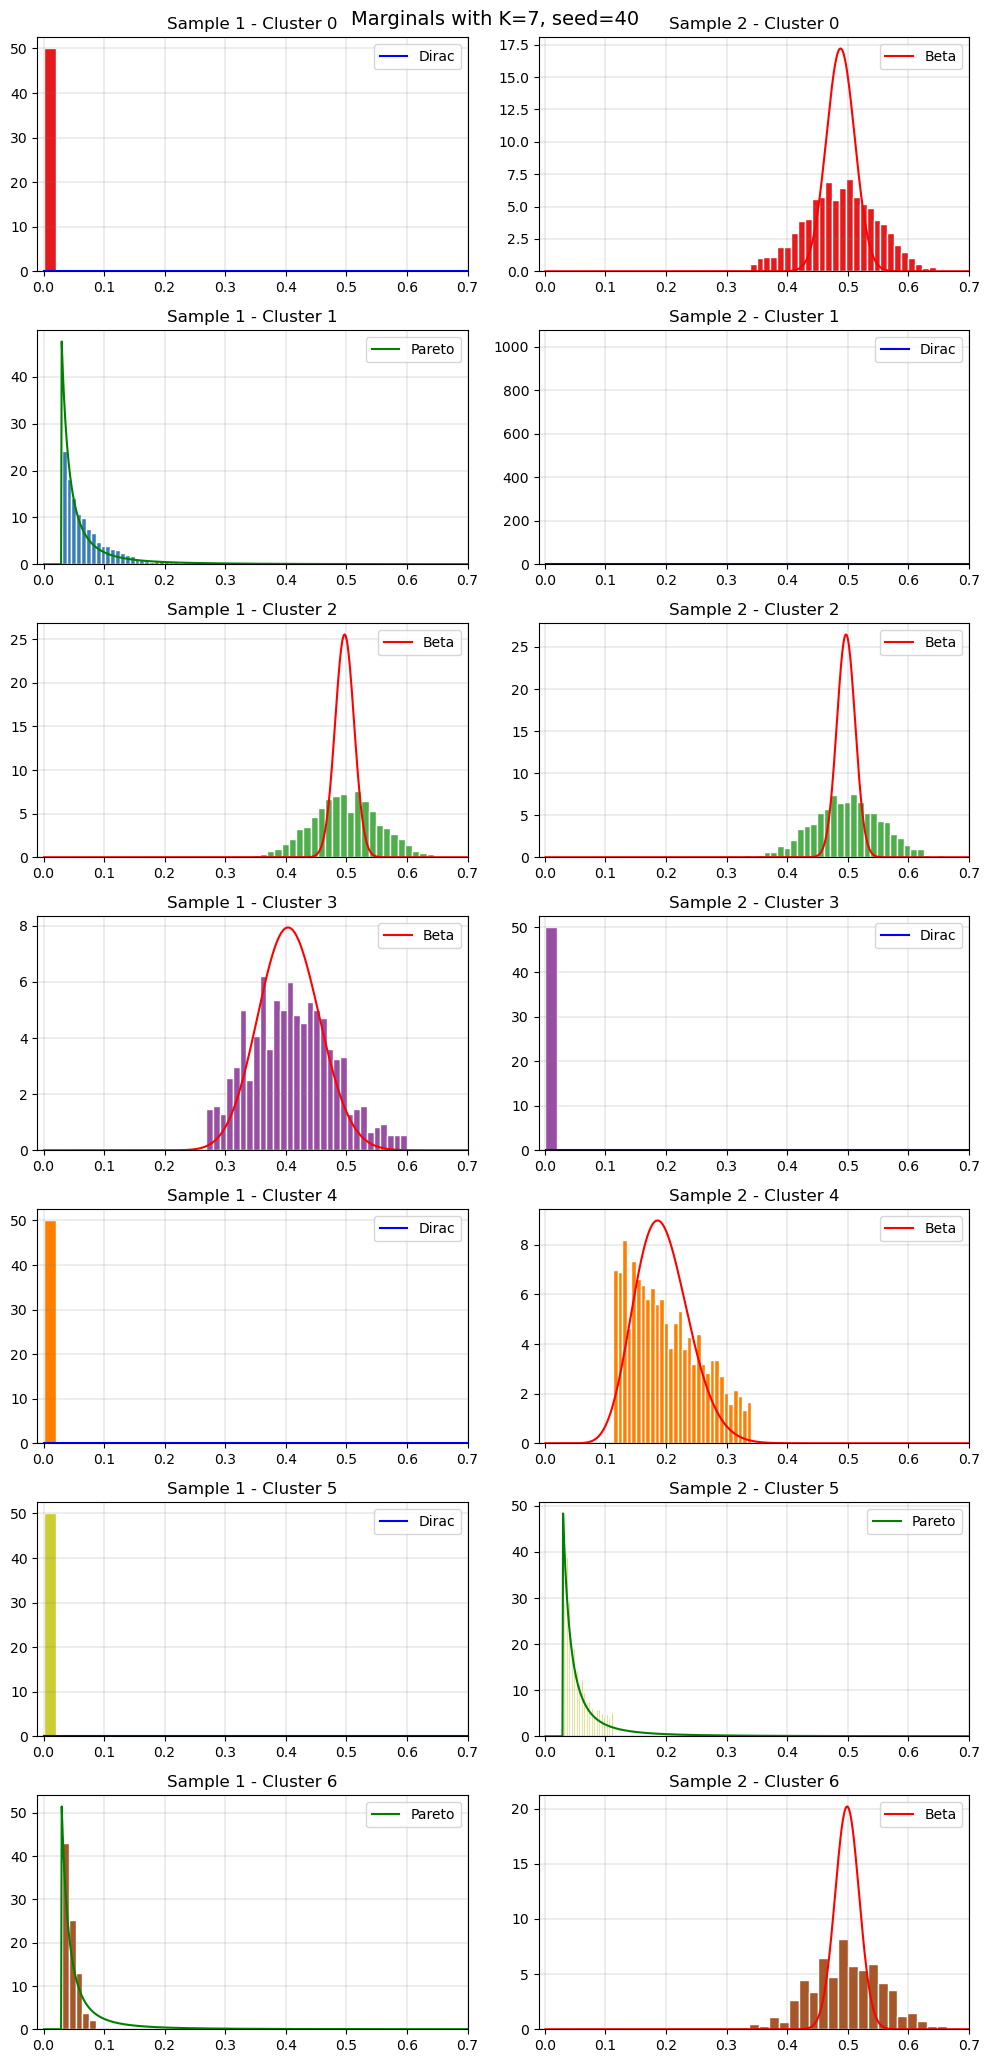

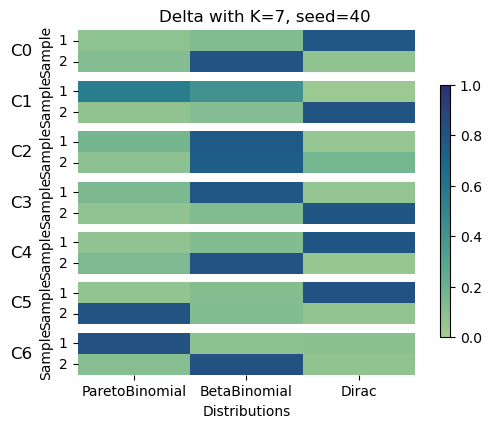

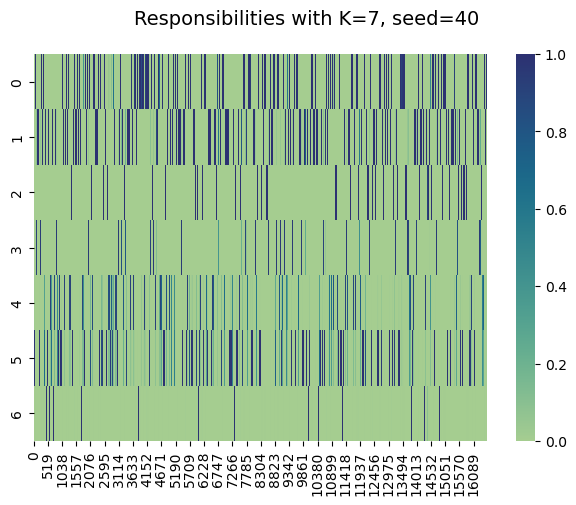

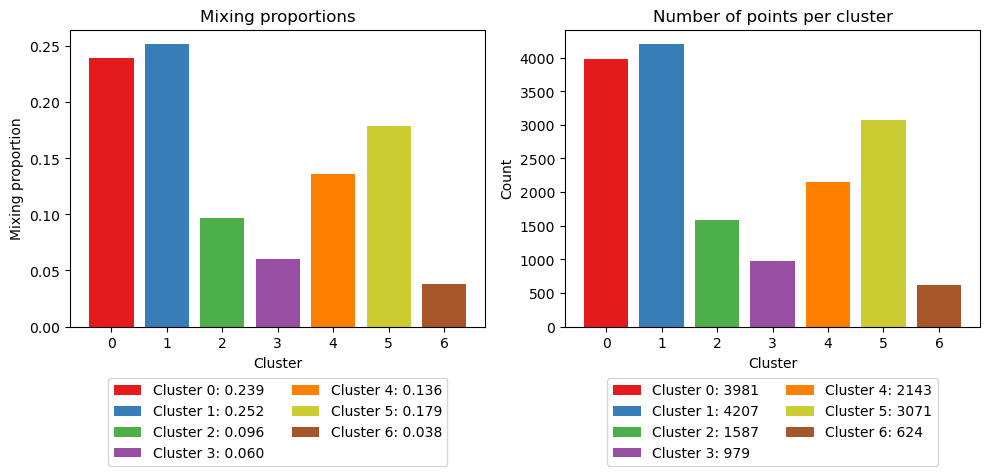

In [43]:
plot_scatter_inference(mb['best_fit'], save_folder= 'test_data')
plot_bic_icl(mb)
plot_marginals_inference(mb['best_fit'])
plot_marginals_single(mb['best_fit'])
plot_deltas(mb['best_fit'])
#plot_paretos(mb)
#plot_betas(mb)
plot_responsib(mb['best_fit'])
plot_mixing_proportions(mb['best_fit'])
# plot_loss_lks_dist(mb['best_fit'])

### Test 1D

In [12]:
sets = ['Sample.A', 'Sample.B']

NV_list = []
DP_list = []

for s in sets:
    print(s)
    NV = torch.tensor(data[f'{s}.NV'].to_numpy())
    DP = torch.tensor(data[f'{s}.DP'].to_numpy())
    
    NV_list.append(NV.view(-1, 1))
    DP_list.append(DP.view(-1, 1))

NV = torch.cat(NV_list, dim=1)
DP = torch.cat(DP_list, dim=1)
purity = [1]
mut_id = data['mutation_id'].tolist()
print(NV.shape, DP.shape)

Sample.A
Sample.B
torch.Size([16592, 2]) torch.Size([16592, 2])


In [13]:
NV = NV[:,0]
DP = DP[:,0]
idx = np.where(NV!=0)[0]
NV = NV[idx]
DP = DP[idx]

In [14]:
seed_list = [40,41]
K_list = [2,3,4,5]
mb = model_mobster_mv.fit(
    NV=NV, DP=DP, mut_id=mut_id,
    num_iter=1500, K=K_list,
    seed_list=seed_list, lr=0.01,
    purity=purity,
    n_jobs=-1  # to use all available CPU
)
# mb = model_mobster_mv.fit(NV, DP, num_iter=1500, mut_id=mut_id, K=K_list, seed_list=seed_list, lr=0.01, purity = purity)

RUN WITH K = 2 AND SEED = 40
RUN WITH K = 2 AND SEED = 41
Iteration 0: Loss = 199599436.29835683
Iteration 0: Loss = 199254796.39057946
Iteration 50: Loss = 185903022.98966983
Iteration 50: Loss = 185946004.89730623
Iteration 100: Loss = 182298749.21561295
Iteration 100: Loss = 182583790.0535082
Iteration 150: Loss = 181201293.91545546
Iteration 150: Loss = 181657146.32440495
Iteration 200: Loss = 180823433.64930016
Iteration 200: Loss = 181357155.30862245
RUN WITH K = 4 AND SEED = 40
RUN WITH K = 3 AND SEED = 40
RUN WITH K = 4 AND SEED = 41
RUN WITH K = 3 AND SEED = 41
RUN WITH K = 5 AND SEED = 41
RUN WITH K = 5 AND SEED = 40
Iteration 250: Loss = 180753218.3584065
Iteration 250: Loss = 181236988.72709817
Iteration 300: Loss = 180732479.59050292
Iteration 300: Loss = 181154026.71503413
Iteration 0: Loss = 198766460.33231094
Iteration 0: Loss = 203024145.77234247
Iteration 0: Loss = 200349294.99280465
Iteration 0: Loss = 201237170.41820994
Iteration 0: Loss = 200102880.38710138
Iterati

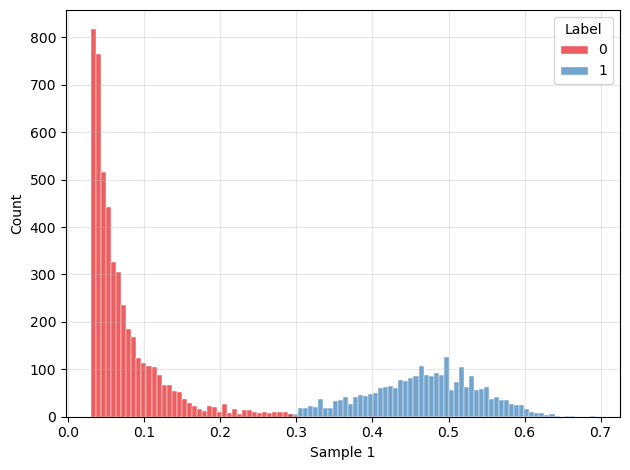

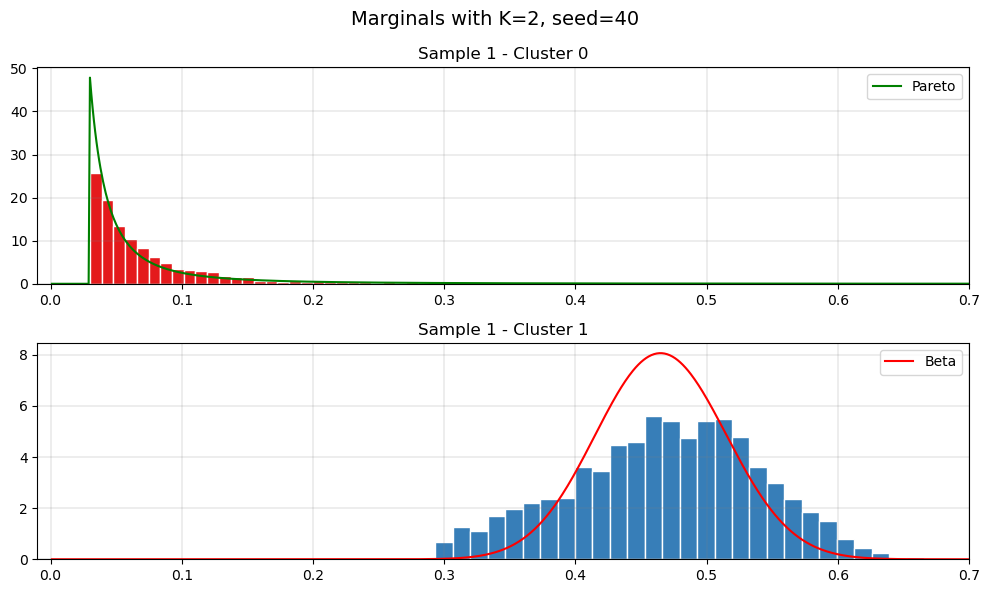

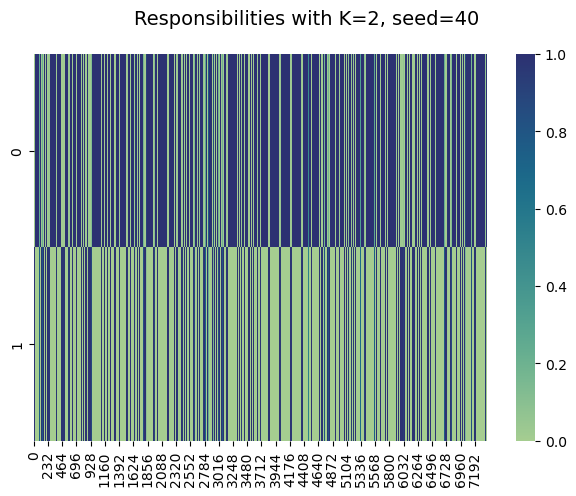

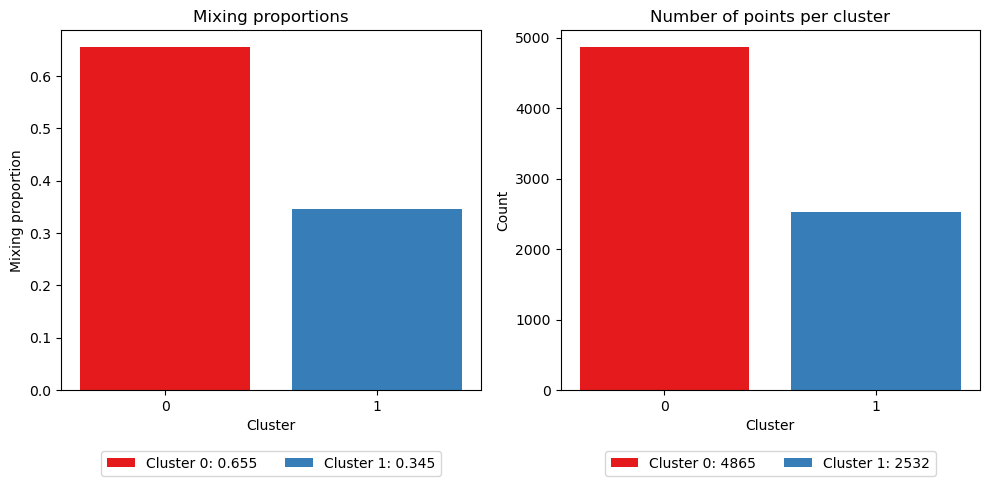

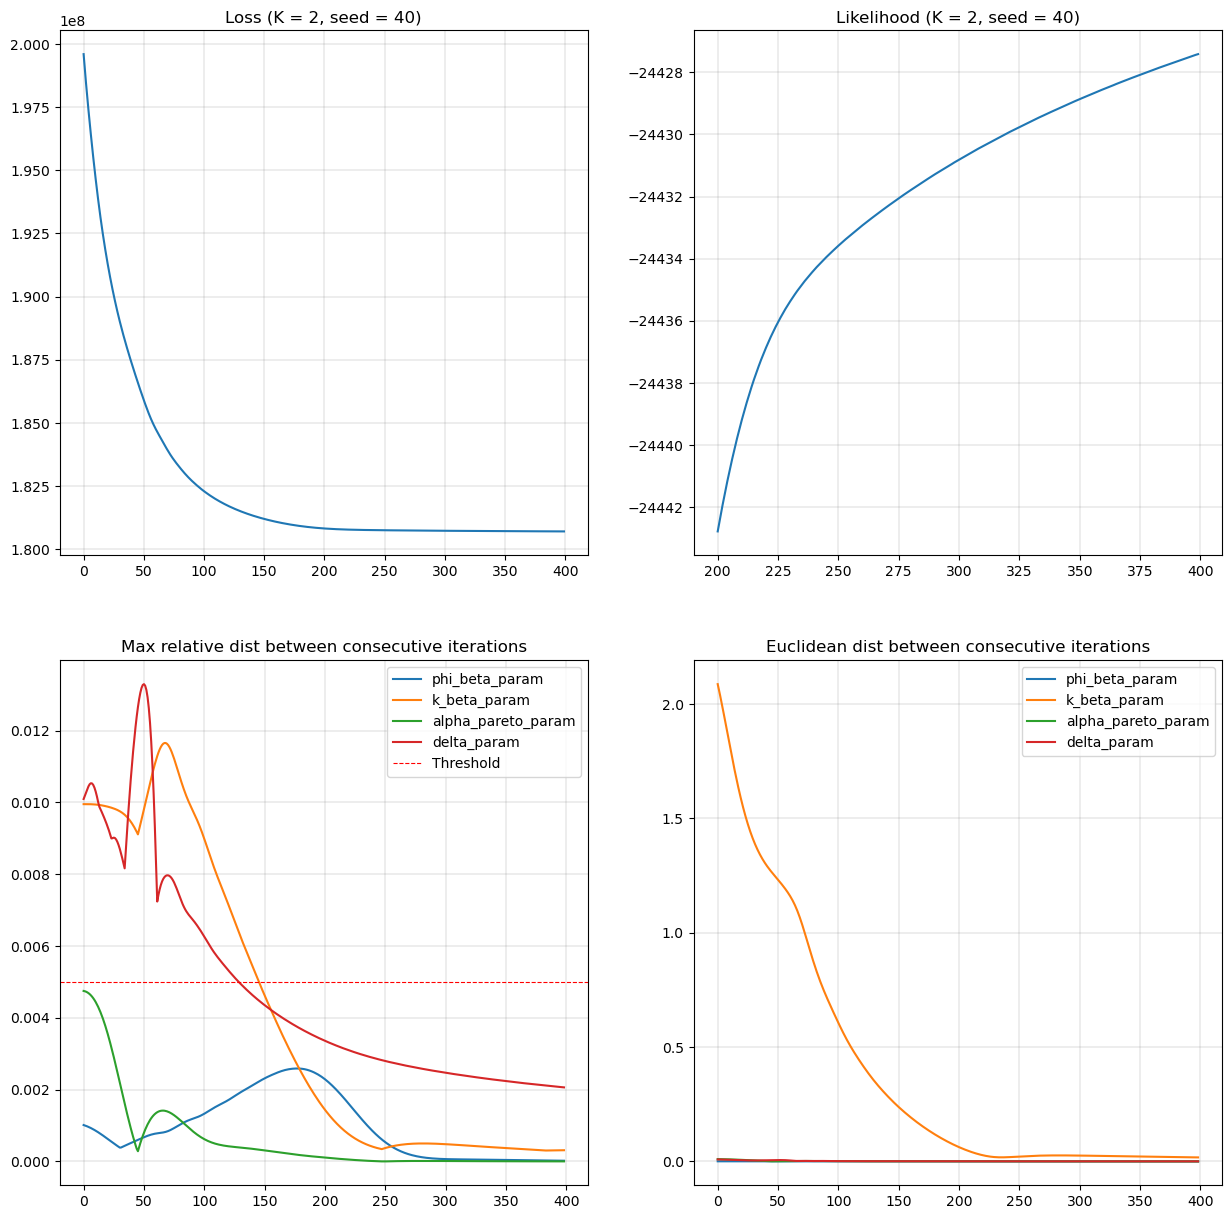

In [15]:
plot_marginals_inference(mb['best_fit'])
plot_marginals_single(mb['best_fit'])
plot_responsib(mb['best_fit'])
plot_mixing_proportions(mb['best_fit'])
plot_loss_lks_dist(mb['best_fit'])